# DR History Analysis

This script looks at 2026 networks and DR event logs from 2011 through 2025. The goal is to inform maximum DR participation estimates. I am primarily concerned with the frequency and type of DLRP events by network in order to understand if there are any generalizable characteristics of networks with immediate or contingent DLRP events.

## Notes
* Network tiers shift slightly year to year, so it can't be relied on for an analysis
* Some years have different asterisk meanings. See this document for details https://www.coned.com/-/media/files/coned/documents/save-energy-money/rebates-incentives-tax-credits/smart-usage-rewards/demand-response-events.pdf?la=en
* Brownsville Networks = Crown Heights, Richmond Hill, Ridgewood

In [51]:
import pandas as pd
import matplotlib.pyplot as plt  # for visualization
from datetime import datetime
from statistics import median


# 2026 Networks

In [52]:
# read in hardware data to dataframe
networks_df = pd.read_csv('data/conEdNetworks2026.csv')

networks_df.head()

,borough,network,start time,end time,tier
0,bronx,central bronx,19:00,23:00,2
1,bronx,fordham,16:00,20:00,2
2,bronx,northeast bronx,16:00,20:00,1
3,bronx,riverdale,16:00,20:00,1
4,bronx,southeast bronx,16:00,20:00,1


In [53]:
networks_df.shape

(83, 5)

In [54]:
allN = list(networks_df['network'])
allN

['central bronx',
 'fordham',
 'northeast bronx',
 'riverdale',
 'southeast bronx',
 'west bronx',
 'bay ridge',
 'borough hall',
 'brighton beach',
 'crown heights',
 'flatbush',
 'ocean parkway',
 'park slope',
 'prospect park',
 'ridgewood',
 'sheepshead bay',
 'williamsburg',
 'battery park city',
 'beekman',
 'bowling green',
 'canal',
 'central park',
 'chelsea',
 'city hall',
 'columbus circle',
 'cooper square',
 'cortlandt',
 'empire',
 'fashion',
 'freedom',
 'fulton',
 'grand central',
 'greeley square',
 'greenwich',
 'harlem',
 'herald square',
 'hudson',
 'hunter',
 'kips bay',
 'lenox hill',
 'lincoln square',
 'madison square',
 'morgan',
 'midtown west',
 'park place',
 'pennsylvania',
 'plaza',
 'rockefeller center',
 'roosevelt',
 'sheridan square',
 'sutton',
 'times square',
 'triboro',
 'turtle bay',
 'washington heights',
 'yorkville',
 'borden',
 'flushing',
 'jackson heights',
 'jamaica',
 'long island city',
 'maspeth',
 'rego park',
 'richmond hill',
 'sunnys

In [55]:
# list(networks_df[networks_df['network']=='fordham']['borough'])[0]

In [56]:
#get list of non-manhattan networks
nM = list(networks_df[networks_df['borough']!= 'manhattan']['network'])
print(nM)

#get list of manhattan networks
mN =  list(networks_df[networks_df['borough']== 'manhattan']['network'])

['central bronx', 'fordham', 'northeast bronx', 'riverdale', 'southeast bronx', 'west bronx', 'bay ridge', 'borough hall', 'brighton beach', 'crown heights', 'flatbush', 'ocean parkway', 'park slope', 'prospect park', 'ridgewood', 'sheepshead bay', 'williamsburg', 'borden', 'flushing', 'jackson heights', 'jamaica', 'long island city', 'maspeth', 'rego park', 'richmond hill', 'sunnyside', 'fox hills', 'fresh kills', 'wainwright', 'willowbrook', 'woodrow', 'buchanan', 'cedar street', 'elmsford no. 2', 'granite hill', 'grasslands', 'harrison', 'millwood west', 'mohansic', 'washington street', 'white plains', 'pleasantville', 'rockview', 'ossining west']


In [57]:
#get representative networks
#repNet = {}
for t in range(2):
    tN = networks_df.loc[networks_df['tier']== t+1]
    for ti in ['11:00','14:00','16:00','19:00']:
        tNT = tN.loc[tN['start time']==ti]
        
        for b in range(2):
            if b == 0:
                bL = ['bronx', 'brooklyn', 'manhattan', 'queens']
            else:
                bL = ['staten island','westchester']
                     
            tNTB = tNT.loc[tNT['borough'].isin(bL)]
            print('B' + str(b+1) +'_T'+str(t+1) + '_S'+ str(ti) + ': ' + str(tNTB.shape[0]))

B1_T1_S11:00: 21
B2_T1_S11:00: 0
B1_T1_S14:00: 14
B2_T1_S14:00: 0
B1_T1_S16:00: 20
B2_T1_S16:00: 12
B1_T1_S19:00: 0
B2_T1_S19:00: 6
B1_T2_S11:00: 0
B2_T2_S11:00: 0
B1_T2_S14:00: 2
B2_T2_S14:00: 0
B1_T2_S16:00: 6
B2_T2_S16:00: 0
B1_T2_S19:00: 2
B2_T2_S19:00: 0


In [107]:
#percentage of tier 2 networks
networks_df[networks_df['tier']==2].shape[0]/int(networks_df.shape[0])

0.12048192771084337

In [59]:
t1_networks = list(networks_df[networks_df['tier']==1]['network'])
t2_networks = list(networks_df[networks_df['tier']==2]['network'])

# DR Event Logs

In [60]:
# read in logs to dataframe

log_df = pd.read_csv('data/DR-activitylog-cleaned_2025.csv')

#convert event dates to datetime format
log_df['Event Date'] = pd.to_datetime(log_df['Event Date'])

print(log_df.shape)
log_df.head()

(1015, 9)


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
0,2011-06-08,Con Edison,DLC,15:00,16:00,1:00,All,Test,NaN
1,2011-06-08,Con Edison,DLRP,15:00,16:00,1:00,All,Test,NaN
2,2011-06-08,Con Edison,RSAP,16:00,17:00,1:00,Zone J,Test,NaN
3,2011-06-09,Con Edison,CSRP,14:00,15:00,1:00,All,Test,NaN
4,2011-06-09,Con Edison,CSRP,17:00,18:00,1:00,All,Test,NaN


In [61]:
# filter out all NYISO
flog_df = log_df[log_df['Administrator']=='Con Edison']
print(flog_df.shape)

#filter out tests
flog_df = flog_df[log_df['Event/Test']!='Test']
print(flog_df.shape)
flog_df.head()

(903, 9)
(815, 9)


C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\294374127.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flog_df = flog_df[log_df['Event/Test']!='Test']


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
7,2011-07-21,Con Edison,DLC,13:00,18:00,5:00,All,Event,NaN
8,2011-07-21,Con Edison,RSAP,11:00,19:00,8:00,Zone J,Event,NaN
9,2011-07-21,Con Edison,CSRP-Day,12:00,17:00,5:00,All,Event,NaN
10,2011-07-21,Con Edison,CSRP-Night,17:00,22:00,5:00,All,Event,NaN
13,2011-07-22,Con Edison,DLC,7:00,15:00,8:00,Elmsford No. 2,Event,NaN


In [62]:
flog_df.tail()

,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
1007,2025-07-29,Con Edison,Term-DLM & Auto-DLM,11:00,23:00,12:00,System Wide,Event,Term DLM Planned
1008,2025-07-29,Con Edison,CSRP*,10:00,23:00,4:00,System Wide,Event,CSRP Planned
1010,2025-07-30,Con Edison,Term-DLM & Auto-DLM,11:00,23:00,12:00,System Wide,Event,Term DLM Planned
1011,2025-07-30,Con Edison,CSRP*,10:00,23:00,4:00,System Wide,Event,CSRP Planned
1012,2025-07-30,Con Edison,DLRP,11:00,17:00,6:00,Elmsford No. 2,Event,DLRP Immediate


In [63]:
# Remove asterisks from the column
flog_df['Program'] = flog_df['Program'].str.replace('*', '', regex=False)


## DLRP analysis

In [64]:
#filter out non DLRP events
dlog_df = flog_df[flog_df['Program'].isin(['DLRP'])]

print(dlog_df.shape)
dlog_df.head()

(208, 9)


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
25,2011-07-22,Con Edison,DLRP,7:00,15:00,8:00,Elmsford No. 2,Event,NaN
26,2011-07-22,Con Edison,DLRP,7:00,15:00,8:00,Maspeth,Event,NaN
27,2011-07-22,Con Edison,DLRP,18:00,23:00,5:00,Richmond Hill,Event,NaN
28,2011-07-22,Con Edison,DLRP,18:00,23:00,5:00,Fox Hills,Event,NaN
29,2011-07-22,Con Edison,DLRP,18:00,23:00,5:00,Sheepshead Bay,Event,NaN


In [65]:
#filter out NaN event types
dlog_df = dlog_df[flog_df['Event Type'].notnull()]

print(dlog_df.shape)
dlog_df.head()

(172, 9)


C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\2038490168.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dlog_df = dlog_df[flog_df['Event Type'].notnull()]


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
171,2016-07-15,Con Edison,DLRP,14:00,20:00,6:00,Fresh Kills,Event,Immediate
173,2016-07-22,Con Edison,DLRP,17:00,23:00,6:00,Fox Hills,Event,Immediate
174,2016-07-23,Con Edison,DLRP,22:00,0:00,2:00,Triboro,Event,Immediate
176,2016-07-24,Con Edison,DLRP,6:00,10:00,4:00,Riverdale,Event,Contingency
195,2016-08-11,Con Edison,DLRP,14:00,20:00,6:00,Crown Heights,Event,Contingency


In [66]:
#args: list of networks
brownsvilleNetworks = ['crown heights', 'richmond hill', 'ridgewood']

def getUnique(l):
    nL = []
    #loop through list
    for n in l:
        n = n.lower()
        #replace Brownsville group with actual network names
        if n == 'brownsville*':
            for b in brownsvilleNetworks :
                if b not in nL:
                    nL.append(b)
        elif n == 'all^':
            #in 2019 All^ exlcludes Manhattan, Borough Hall, and Brownsville
            #in 2020 All^ excludes Brownsville Networks but this is not present in the filtered data
            #loop through all networks
            for nn in allN:
                #exclude browseville networks
                if nn not in brownsvilleNetworks:
                    #exclude manhattan networks
                    if nn not in mN:
                        if nn != 'borough hall':
                            #check if already in list
                            if nn not in nL:
                                nL.append(nn) 
        elif n == 'non-manhattan**':
            #in 2019 Non-Manhattan** excludes Brownsville (BQDM) networks but this is not present in the filtered data
            #in 2020 Non-Manhattan** excludes Borough Hall
            #loop through all non-manhattan networks
            for nn in nM:
                if nn not in nL:
                    if nn != 'borough hall':
                        nL.append(nn)
        elif n == 'non-manhattan***':
            #in 2020 Non-Manhattan*** includes Washington Heights in Manhattan. Excludes Borough Hall
            for nn in nM:
                if nn not in nL:
                    if nn != 'borough hall':
                        nL.append(nn)
            if 'washington heights' not in nL:
                nL.append('washington heights')
        elif ',' in n or ' and ' in n or '&' in n:
            parts = n.replace(' and ', ',').replace('&', ',').split(',')
            for p in parts:
                p = p.strip()
                if p not in nL:
                    nL.append(p)
        else:
            if 'sc 11' in n:
                n = n.replace('sc 11','').strip()
            if n not in nL:
                nL.append(n)
        
    return nL
        

In [67]:
#dlog_df['Zone/Network'] = dlog_df['Zone/Network'].str.replace('SC 11', '', regex=False)

In [68]:
print(dlog_df['Zone/Network'].unique())

#list of networks that have had DLRP events of either type
DLRPuN = getUnique(dlog_df['Zone/Network'].unique())

#print network names
print(DLRPuN)

#print amount of networks
print(len(DLRPuN))

#print percentage of total networks
len(DLRPuN)/networks_df.shape[0]

['Fresh Kills' 'Fox Hills' 'Triboro' 'Riverdale' 'Crown Heights'
 'Ridgewood' 'Richmond Hill' 'Sheepshead Bay' 'Williamsburg'
 'Prospect Park' 'Central Park' 'Madison Square' 'Cooper Square'
 'Brownsville*' 'Willowbrook' 'All^' 'Flatbush' 'Wainwright' 'Bay Ridge'
 'Rego Park' 'Non-Manhattan**' 'Maspeth' 'Southeast Bronx'
 'Non-Manhattan***' 'Borough Hall' 'Yorkville' 'Jamaica' 'City Hall'
 'Ossining West' 'Park Slope' 'Central Bronx' 'Cedar Street'
 'Washington Street' 'Elmsford No. 2' 'Jackson Heights' 'Borden'
 'Sunnyside' 'Granite Hill' 'White Plains' 'Sutton' 'Fordham'
 'Fordham SC 11' 'Millwood West' 'Harrison'
 'Crown Heights, Richmond Hill, Ridgewood' 'Elmsford No. 2 and Harrison'
 'Harlem' 'Bay Ridge & Park Slope'
 'Crown Heights, Ridgewood, Richmond Hill']
['fresh kills', 'fox hills', 'triboro', 'riverdale', 'crown heights', 'ridgewood', 'richmond hill', 'sheepshead bay', 'williamsburg', 'prospect park', 'central park', 'madison square', 'cooper square', 'willowbrook', 'centra

0.6385542168674698

In [69]:
#networks that have never experienced DLRP events
nonDLRP = []
for n in allN:
    if n not in DLRPuN:
        nonDLRP.append(n)

print(len(nonDLRP))
display(networks_df[networks_df['network'].isin(nonDLRP)])


30


,borough,network,start time,end time,tier
17,manhattan,battery park city,11:00,15:00,1
18,manhattan,beekman,11:00,15:00,1
19,manhattan,bowling green,11:00,15:00,1
20,manhattan,canal,14:00,18:00,1
22,manhattan,chelsea,14:00,18:00,1
24,manhattan,columbus circle,14:00,18:00,1
26,manhattan,cortlandt,11:00,15:00,1
27,manhattan,empire,11:00,15:00,1
28,manhattan,fashion,14:00,18:00,1
29,manhattan,freedom,11:00,15:00,1


### Analysis of Immediate Events

In [70]:
#immediate events
#filter out NaN event types
elog_df = dlog_df[(dlog_df['Event Type']=='Immediate') | (dlog_df['Event Type']=='DLRP Immediate')]

uniIE = getUnique(elog_df['Zone/Network'].unique())

print(len(uniIE))
print(len(uniIE)/networks_df.shape[0])
print(uniIE)
elog_df.head()

31
0.37349397590361444
['fresh kills', 'fox hills', 'triboro', 'williamsburg', 'prospect park', 'willowbrook', 'flatbush', 'bay ridge', 'southeast bronx', 'yorkville', 'maspeth', 'central park', 'jamaica', 'rego park', 'city hall', 'ossining west', 'ridgewood', 'central bronx', 'cedar street', 'washington street', 'elmsford no. 2', 'jackson heights', 'granite hill', 'white plains', 'fordham', 'millwood west', 'harrison', 'richmond hill', 'park slope', 'crown heights', 'harlem']


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
171,2016-07-15,Con Edison,DLRP,14:00,20:00,6:00,Fresh Kills,Event,Immediate
173,2016-07-22,Con Edison,DLRP,17:00,23:00,6:00,Fox Hills,Event,Immediate
174,2016-07-23,Con Edison,DLRP,22:00,0:00,2:00,Triboro,Event,Immediate
215,2016-08-12,Con Edison,DLRP,17:00,22:00,5:00,Fox Hills,Event,Immediate
216,2016-08-12,Con Edison,DLRP,16:00,0:00,8:00,Fresh Kills,Event,Immediate


In [71]:
#get representative networks for those that have had DLRP immediate events

nG = []
for iN in getUnique(uniIE):
    tempN = networks_df[networks_df['network']== iN.lower()]
    if list(tempN['borough'])[0] in ['staten island','westchester']:
        nG.append("T" + str(list(tempN['tier'])[0]) + " B2 " + str(list(tempN['start time'])[0]))
    else:
        nG.append("T" + str(list(tempN['tier'])[0]) + " B1 " + str(list(tempN['start time'])[0]))
        
    
print(list(nG))

nGDict = dict(zip(set(nG),[0] * len(set(nG))))

for n in nG:
    nGDict[n] = nGDict[n] + 1
    
nGDict
# set(nG)
        #repNet = {}
# for t in range(2):
#     tN = networks_df.loc[networks_df['tier']== t+1]
#     for ti in ['11:00','14:00','16:00','19:00']:
#         tNT = tN.loc[tN['start time']==ti]
        
#         for b in range(2):
#             if b == 0:
#                 bL = ['bronx', 'brooklyn', 'manhattan', 'queens']
#             else:
#                 bL = 
                     
#             tNTB = tNT.loc[tNT['borough'].isin(bL)]
#             print('B' + str(b+1) +'_T'+str(t+1) + '_S'+ str(ti) + ': ' + str(tNTB.shape[0]))

['T1 B2 19:00', 'T1 B2 16:00', 'T1 B1 16:00', 'T2 B1 16:00', 'T1 B1 16:00', 'T1 B2 19:00', 'T1 B1 16:00', 'T1 B1 14:00', 'T1 B1 16:00', 'T1 B1 16:00', 'T1 B1 16:00', 'T1 B1 16:00', 'T2 B1 19:00', 'T1 B1 16:00', 'T1 B1 11:00', 'T1 B2 19:00', 'T2 B1 16:00', 'T2 B1 19:00', 'T1 B2 16:00', 'T1 B2 16:00', 'T1 B2 16:00', 'T2 B1 16:00', 'T1 B2 16:00', 'T1 B2 16:00', 'T2 B1 16:00', 'T1 B2 16:00', 'T1 B2 16:00', 'T2 B1 16:00', 'T2 B1 14:00', 'T1 B1 16:00', 'T1 B1 16:00']


{'T2 B1 16:00': 5,
 'T1 B1 16:00': 10,
 'T2 B1 14:00': 1,
 'T1 B2 16:00': 8,
 'T1 B1 14:00': 1,
 'T1 B2 19:00': 3,
 'T1 B1 11:00': 1,
 'T2 B1 19:00': 2}

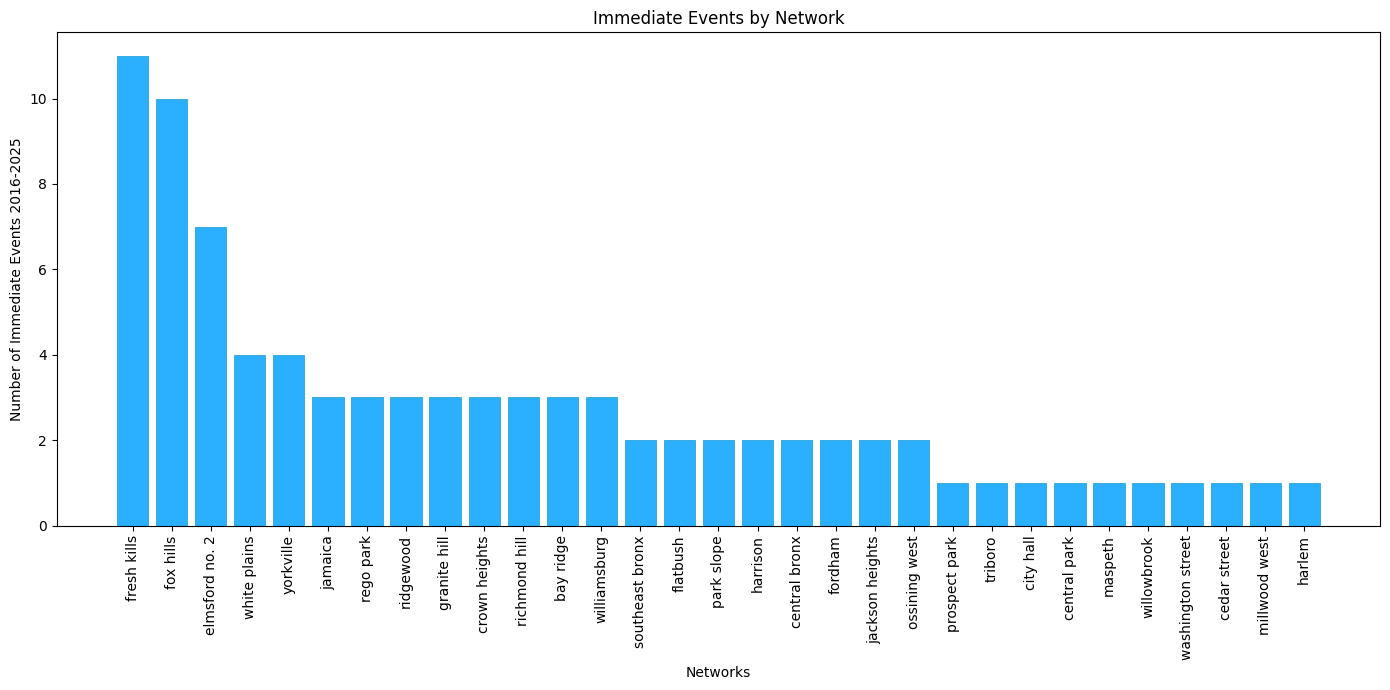

In [84]:
# # Histogram of networks with DLRP events

# plt.figure(figsize=(14,7)) # Make it 14x7 inch
# plt.hist(elog_df['Zone/Network'], bins=len(elog_df['Zone/Network'].unique()), facecolor = '#2ab0ff', edgecolor='#169acf', linewidth=0.5)
# plt.title('Immediate Events by Network') 
# plt.xlabel('Networks') 
# plt.xticks(rotation='vertical')
# plt.ylabel('Number of Immediate Events 2016-2025') 
# plt.show()

def expandNetworkGroup(n):
    """Given a raw Zone/Network string, return the list of individual
    real network names it represents (lowercase), expanding both the
    aggregate codes (Brownsville*, All^, etc.) and ad-hoc comma/'and'/'&'
    separated groups like 'Crown Heights, Richmond Hill, Ridgewood'."""
    n = n.lower().strip()
    if 'sc 11' in n:
        n = n.replace('sc 11', '').strip()

    if n == 'brownsville*':
        return list(brownsvilleNetworks)
    elif n == 'all^':
        return [nn for nn in allN
                if nn not in brownsvilleNetworks
                and nn not in mN
                and nn != 'borough hall']
    elif n == 'non-manhattan**':
        return [nn for nn in nM if nn != 'borough hall']
    elif n == 'non-manhattan***':
        base = [nn for nn in nM if nn != 'borough hall']
        if 'washington heights' not in base:
            base.append('washington heights')
        return base
    elif ',' in n or ' and ' in n or '&' in n:
        parts = n.replace(' and ', ',').replace('&', ',').split(',')
        return [p.strip() for p in parts if p.strip()]
    else:
        return [n]

# explode elog_df so each event contributes once per real network
expandedNetworks = []
for n in elog_df['Zone/Network']:
    expandedNetworks.extend(expandNetworkGroup(n))

networkCounts = pd.Series(expandedNetworks).value_counts().sort_values(ascending=False)

# Bar chart of networks with DLRP immediate events
plt.figure(figsize=(14,7))
plt.bar(networkCounts.index, networkCounts.values,
        facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Immediate Events by Network')
plt.xlabel('Networks')
plt.xticks(rotation='vertical')
plt.ylabel('Number of Immediate Events 2016-2025')
plt.tight_layout()
plt.show()

C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\2894061265.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elog_df['Month'] = elog_df['Event Date'].dt.month


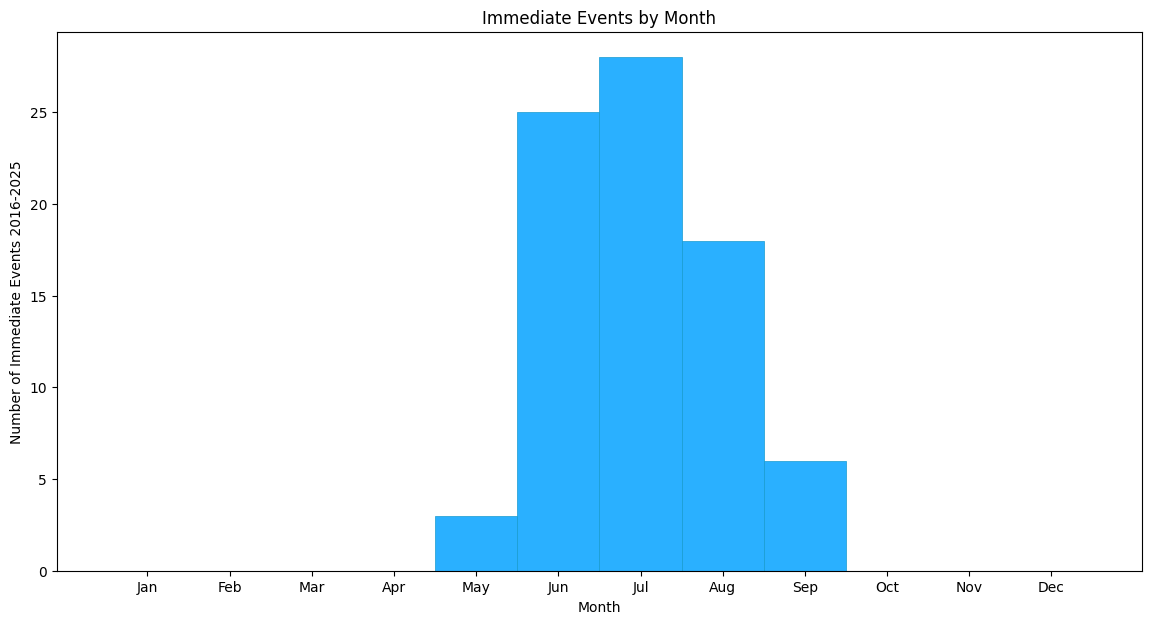

average month: 6.99
median month: 7.0
most common month: 7


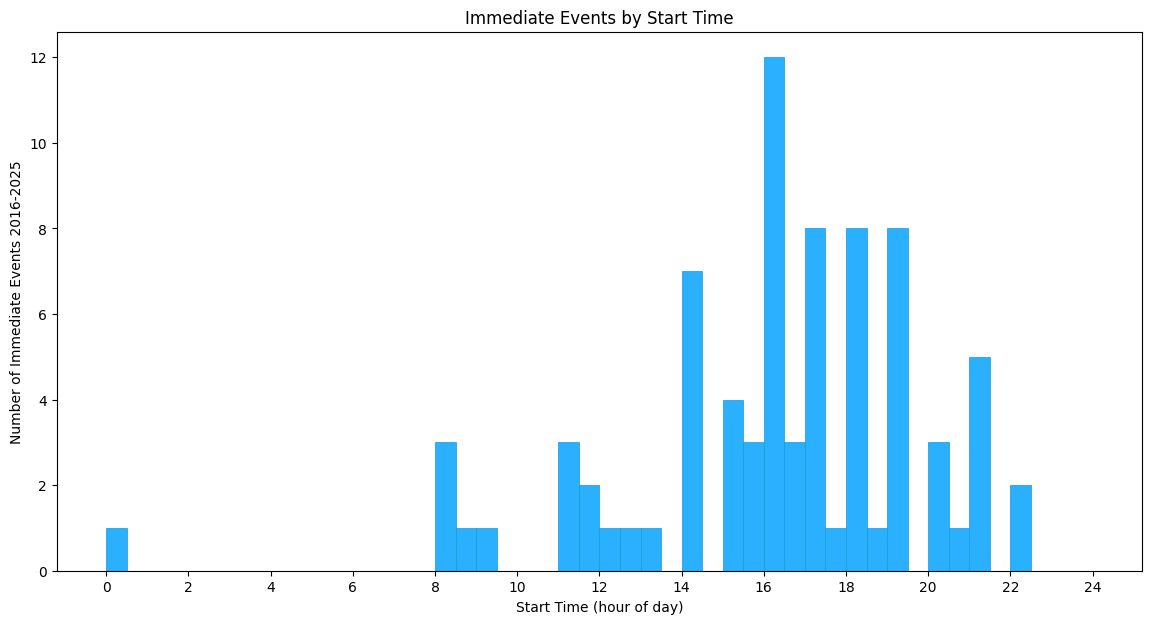

average start time: 15.98
median start time: 16.25
most common start time: 16.0
overall median event date: 2023-07-28


In [90]:
# --- Histogram of immediate events by month ---
elog_df['Month'] = elog_df['Event Date'].dt.month

plt.figure(figsize=(14,7))
plt.hist(elog_df['Month'], bins=range(1, 14), align='left',
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Immediate Events by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Number of Immediate Events 2016-2025')
plt.show()

print(f'average month: {elog_df["Month"].mean():.2f}')
print(f'median month: {elog_df["Month"].median()}')
print(f'most common month: {elog_df["Month"].mode().iloc[0]}')

# --- Histogram of immediate events by start time ---
plt.figure(figsize=(14,7))
plt.hist(elog_df['Start Time Float'], bins=[h + m/60 for h in range(0, 25) for m in (0, 30)][:-1],
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Immediate Events by Start Time')
plt.xlabel('Start Time (hour of day)')
plt.xticks(range(0, 25, 2))
plt.ylabel('Number of Immediate Events 2016-2025')
plt.show()

print(f'average start time: {elog_df["Start Time Float"].mean():.2f}')
print(f'median start time: {elog_df["Start Time Float"].median()}')
print(f'most common start time: {elog_df["Start Time Float"].mode().iloc[0]}')

# --- Overall median across the full event date range ---
print(f'overall median event date: {elog_df["Event Date"].median().date()}')

In [102]:
# Explode elog_df into one row per (individual network, event) pair
expanded_rows = []
for _, row in elog_df.iterrows():
    for net in expandNetworkGroup(row['Zone/Network']):
        expanded_rows.append({'network': net, 'year': row['Event Date'].year})

exp_df = pd.DataFrame(expanded_rows)

# --- Most immediate events a single network experienced in a single year ---
network_year_counts = exp_df.groupby(['network', 'year']).size()

max_events_in_year = network_year_counts.max()
top_network_years = network_year_counts[network_year_counts == max_events_in_year]

print(f'Most immediate events a single network experienced in one year: {max_events_in_year}')
for (net, yr), count in top_network_years.items():
    print(f'  {net} in {yr}: {count} events')

# --- Maximum number of distinct years any network experienced an immediate event ---
years_per_network = exp_df.groupby('network')['year'].nunique()

max_years = years_per_network.max()
top_networks = years_per_network[years_per_network == max_years]

print(f'\nMaximum number of years any network experienced an immediate event: {max_years}')
for net, yrs in top_networks.items():
    print(f'  {net}: {yrs} years')

Most immediate events a single network experienced in one year: 3
  crown heights in 2025: 3 events
  elmsford no. 2 in 2024: 3 events
  elmsford no. 2 in 2025: 3 events
  fox hills in 2016: 3 events
  fresh kills in 2016: 3 events
  fresh kills in 2023: 3 events
  richmond hill in 2025: 3 events
  white plains in 2025: 3 events

Maximum number of years any network experienced an immediate event: 6
  fox hills: 6 years
  fresh kills: 6 years


In [105]:
# Total immediate events per network (summed across all years)
events_per_network = exp_df.groupby('network').size()

# Combine years-active and total-events-per-network
network_summary = pd.DataFrame({
    'years': years_per_network,
    'events': events_per_network
})

print('Number of networks by years with an immediate event, broken out by event count:')
for num_years in sorted(network_summary['years'].unique()):
    subset = network_summary[network_summary['years'] == num_years]
    print(f'{num_years} year{"s" if num_years != 1 else ""}: {subset.shape[0]} networks')

    event_counts = subset['events'].value_counts().sort_index()
    for num_events, num_networks in event_counts.items():
        print(f'    {num_events} event{"s" if num_events != 1 else ""}: {num_networks} network{"s" if num_networks != 1 else ""}')

print(f'\nTotal networks with at least one immediate event: {years_per_network.shape[0]}')

Number of networks by years with an immediate event, broken out by event count:
1 year: 16 networks
    1 event: 10 networks
    2 events: 4 networks
    3 events: 2 networks
2 years: 9 networks
    2 events: 4 networks
    3 events: 3 networks
    4 events: 2 networks
3 years: 4 networks
    3 events: 3 networks
    7 events: 1 network
6 years: 2 networks
    10 events: 1 network
    11 events: 1 network

Total networks with at least one immediate event: 31


In [113]:
# Rebuild expanded rows with month included
expanded_rows = []
for _, row in elog_df.iterrows():
    for net in expandNetworkGroup(row['Zone/Network']):
        expanded_rows.append({
            'network': net,
            'year': row['Event Date'].year,
            'month': row['Event Date'].month
        })

exp_df = pd.DataFrame(expanded_rows)

# Only network-years with 2+ events are relevant to "same month?" question
multi_event_years = exp_df.groupby(['network', 'year']).filter(lambda g: len(g) > 1)
groups = multi_event_years.groupby(['network', 'year'])

# --- Metric 1: fraction of network-years where ALL events fell in the same month ---
same_month_flags = groups['month'].apply(lambda m: m.nunique() == 1)

num_multi_years = same_month_flags.shape[0]
num_all_same_month = same_month_flags.sum()

print(f'Network-years with 2+ immediate events: {num_multi_years}')
print(f'Of those, all events in the same month: {num_all_same_month} '
      f'({num_all_same_month/num_multi_years:.1%})')

# --- Metric 2: pairwise -- of all pairs of events in the same network-year, ---
# --- what fraction fall in the same month? (more granular for 3+ event years) ---
from itertools import combinations

same_pair_count = 0
total_pair_count = 0
for (_, _), g in groups:
    months = list(g['month'])
    for m1, m2 in combinations(months, 2):
        total_pair_count += 1
        if m1 == m2:
            same_pair_count += 1

print(f'\nPairs of events within the same network-year: {total_pair_count}')
print(f'Of those pairs, same month: {same_pair_count} '
      f'({same_pair_count/total_pair_count:.1%})')

# --- Breakdown by number of events that year ---
print('\nBroken out by number of events in the year:')
for n in sorted(groups.size().unique()):
    subset_flags = same_month_flags[groups.size() == n]
    print(f'  {n} events: {subset_flags.sum()}/{subset_flags.shape[0]} network-years '
          f'all in same month ({subset_flags.mean():.1%})')

Network-years with 2+ immediate events: 20
Of those, all events in the same month: 5 (25.0%)

Pairs of events within the same network-year: 36
Of those pairs, same month: 15 (41.7%)

Broken out by number of events in the year:
  2 events: 3/12 network-years all in same month (25.0%)
  3 events: 2/8 network-years all in same month (25.0%)


In [91]:
#convert start times to datetime format
elog_df['DT Format'] = pd.to_datetime(elog_df['Start Time'], format='%H:%M')
elog_df['Start Time Float'] = elog_df['DT Format'].dt.hour + (elog_df['DT Format'].dt.minute/60)
#convert to float
elog_df['Start Time Float'].apply(lambda x: float(x))

C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\1182879215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elog_df['DT Format'] = pd.to_datetime(elog_df['Start Time'], format='%H:%M')
C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\1182879215.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elog_df['Start Time Float'] = elog_df['DT Format'].dt.hour + (elog_df['DT Format'].dt.minute/60)


171     14.0
173     17.0
174     22.0
215     17.0
216     16.0
        ... 
995      9.0
1001    17.0
1002    19.0
1003    16.0
1012    11.0
Name: Start Time Float, Length: 80, dtype: float64

In [194]:
# # Explode elog_df into one row per (individual network, event), carrying Start Time Float
# expanded_rows = []
# for _, row in elog_df.iterrows():
#     for net in expandNetworkGroup(row['Zone/Network']):
#         expanded_rows.append({
#             'network': net,
#             'Start Time Float': row['Start Time Float']
#         })

# exp_time_df = pd.DataFrame(expanded_rows)

# # Merge in borough/tier from networks_df
# exp_time_df = exp_time_df.merge(
#     networks_df[['network', 'borough', 'tier']],
#     on='network',
#     how='left'
# )

# # Flag anything that didn't match networks_df (typos, missing networks, etc.)
# unmatched = exp_time_df[exp_time_df['borough'].isna()]['network'].unique()
# if len(unmatched) > 0:
#     print(f'Warning: {len(unmatched)} network name(s) did not match networks_df: {list(unmatched)}\n')

# # Add borough group: Staten Island + Westchester vs. everything else
# exp_time_df['borough_group'] = exp_time_df['borough'].apply(
#     lambda b: 'staten island / westchester' if b in ['staten island', 'westchester'] else 'other'
# )

# # --- Overall ---
# print('total immediate events:')
# print(elog_df.shape[0])
# print(f'average start time: {elog_df["Start Time Float"].mean()}')
# print(f'median start time: {elog_df["Start Time Float"].median()}')

# # --- By tier ---
# print('\nBy tier:')
# for tier, group in exp_time_df.groupby('tier'):
#     print(f'  Tier {tier}: {group.shape[0]} events, '
#           f'avg start time: {group["Start Time Float"].mean():.2f}, '
#           f'median start time: {group["Start Time Float"].median()}')

# # --- By borough ---
# print('\nBy borough:')
# for borough, group in exp_time_df.groupby('borough'):
#     print(f'  {borough}: {group.shape[0]} events, '
#           f'avg start time: {group["Start Time Float"].mean():.2f}, '
#           f'median start time: {group["Start Time Float"].median()}')

# # --- By borough group (Staten Island/Westchester vs. everything else) ---
# print('\nBy borough group:')
# for group_name, group in exp_time_df.groupby('borough_group'):
#     print(f'  {group_name}: {group.shape[0]} events, '
#           f'avg start time: {group["Start Time Float"].mean():.2f}, '
#           f'median start time: {group["Start Time Float"].median()}')
# Explode elog_df into one row per (individual network, event), carrying Start Time Float
expanded_rows = []
for _, row in elog_df.iterrows():
    for net in expandNetworkGroup(row['Zone/Network']):
        expanded_rows.append({
            'network': net,
            'Start Time Float': row['Start Time Float']
        })
exp_time_df = pd.DataFrame(expanded_rows)

# Merge in borough/tier/assigned start time from networks_df
exp_time_df = exp_time_df.merge(
    networks_df[['network', 'borough', 'tier', 'start time']],
    on='network',
    how='left'
)

# Flag anything that didn't match networks_df (typos, missing networks, etc.)
unmatched = exp_time_df[exp_time_df['borough'].isna()]['network'].unique()
if len(unmatched) > 0:
    print(f'Warning: {len(unmatched)} network name(s) did not match networks_df: {list(unmatched)}\n')

# Add borough group: Staten Island + Westchester vs. everything else
exp_time_df['borough_group'] = exp_time_df['borough'].apply(
    lambda b: 'staten island / westchester' if b in ['staten island', 'westchester'] else 'other'
)

# --- Overall ---
print('total immediate events:')
print(elog_df.shape[0])
print(f'average start time: {elog_df["Start Time Float"].mean()}')
print(f'median start time: {elog_df["Start Time Float"].median()}')

# --- By tier ---
print('\nBy tier:')
for tier, group in exp_time_df.groupby('tier'):
    print(f'  Tier {tier}: {group.shape[0]} events, '
          f'avg start time: {group["Start Time Float"].mean():.2f}, '
          f'median start time: {group["Start Time Float"].median()}')

# --- By borough ---
print('\nBy borough:')
for borough, group in exp_time_df.groupby('borough'):
    print(f'  {borough}: {group.shape[0]} events, '
          f'avg start time: {group["Start Time Float"].mean():.2f}, '
          f'median start time: {group["Start Time Float"].median()}')

# --- By borough group (Staten Island/Westchester vs. everything else) ---
print('\nBy borough group:')
for group_name, group in exp_time_df.groupby('borough_group'):
    print(f'  {group_name}: {group.shape[0]} events, '
          f'avg start time: {group["Start Time Float"].mean():.2f}, '
          f'median start time: {group["Start Time Float"].median()}')

# --- By assigned start time (network's scheduled DLRP window) ---
print('\nBy assigned start time:')
for start_time, group in exp_time_df.groupby('start time'):
    print(f'  {start_time}: {group.shape[0]} events, '
          f'avg actual start time: {group["Start Time Float"].mean():.2f}, '
          f'median actual start time: {group["Start Time Float"].median()}')

total immediate events:
80
average start time: 15.98125
median start time: 16.25

By tier:
  Tier 1: 66 events, avg start time: 16.15, median start time: 16.5
  Tier 2: 20 events, avg start time: 14.82, median start time: 16.0

By borough:
  bronx: 6 events, avg start time: 14.25, median start time: 15.25
  brooklyn: 17 events, avg start time: 15.62, median start time: 16.0
  manhattan: 8 events, avg start time: 17.88, median start time: 19.0
  queens: 12 events, avg start time: 14.83, median start time: 16.0
  staten island: 22 events, avg start time: 16.57, median start time: 17.0
  westchester: 21 events, avg start time: 15.52, median start time: 16.5

By borough group:
  other: 43 events, avg start time: 15.63, median start time: 16.0
  staten island / westchester: 43 events, avg start time: 16.06, median start time: 17.0

By assigned start time:
  11:00: 1 events, avg actual start time: 18.00, median actual start time: 18.0
  14:00: 5 events, avg actual start time: 14.00, median a

In [193]:
elog_df['tier']= 1

elog_df.loc[elog_df['Zone/Network'].str.lower().isin(t2_networks), 'tier'] = 2

elog_df[['Start Time Float','tier']].corr()

C:\Users\alexn\AppData\Local\Temp\ipykernel_35424\3369401083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elog_df['tier']= 1


,Start Time Float,tier
Start Time Float,1.000000,-0.138047
tier,-0.138047,1.000000


In [110]:
#years in which immediate events occurred

#the average time off from the scheduled time
networks_df['immediate years'] = pd.Series()
#the number of immediate events
networks_df['immediate count'] = 0

iE = {}
for r in range(elog_df.shape[0]):
    n = elog_df.iloc[r]['Zone/Network'].lower()
    #s = float(elog_df.iloc[r]['Start Time Float'])
    #nS = networks_df[networks_df['network']==n]['start time float'].iloc[0]#.loc['start time float']
    #v = abs(s - nS)
    eY = elog_df['Event Date'].iloc[r].year
    networks_df.loc[networks_df['network']==n,'immediate count']= networks_df.loc[networks_df['network']==n,'immediate count'] + 1
    if n in iE.keys():
        iE[n].append(eY)
    else:
        iE[n] = [eY]

for n in iE.keys():
    #get unique years
    u = []
    [u.append(x) for x in iE[n] if x not in u]
    networks_df.loc[networks_df['network']==n,'immediate years']= len(u)

print(iE)
networks_df[networks_df['immediate count'] > 0]


{'fresh kills': [2016, 2016, 2016, 2021, 2022, 2022, 2023, 2023, 2023, 2024, 2025], 'fox hills': [2016, 2016, 2016, 2018, 2018, 2019, 2022, 2023, 2023, 2025], 'triboro': [2016], 'williamsburg': [2017, 2021, 2025], 'prospect park': [2017], 'willowbrook': [2019], 'flatbush': [2019, 2021], 'bay ridge': [2019, 2025], 'southeast bronx': [2020, 2022], 'yorkville': [2021, 2021, 2025, 2025], 'maspeth': [2021], 'central park': [2021], 'jamaica': [2021, 2022, 2025], 'rego park': [2021, 2022, 2023], 'city hall': [2022], 'ossining west': [2022, 2022], 'ridgewood': [2022], 'central bronx': [2022, 2023], 'cedar street': [2022], 'washington street': [2023], 'elmsford no. 2': [2023, 2024, 2024, 2024, 2025, 2025], 'jackson heights': [2023, 2025], 'granite hill': [2024, 2024, 2025], 'white plains': [2024, 2025, 2025, 2025], 'fordham': [2024], 'fordham sc 11': [2024], 'millwood west': [2025], 'harrison': [2025], 'richmond hill': [2025], 'park slope': [2025], 'crown heights': [2025], 'elmsford no. 2 and h

,borough,network,start time,end time,tier,immediate years,immediate count
0,bronx,central bronx,19:00,23:00,2,2,2
1,bronx,fordham,16:00,20:00,2,1,1
4,bronx,southeast bronx,16:00,20:00,1,2,2
6,brooklyn,bay ridge,14:00,18:00,1,2,2
9,brooklyn,crown heights,16:00,20:00,1,1,1
10,brooklyn,flatbush,16:00,20:00,1,2,2
12,brooklyn,park slope,14:00,18:00,2,1,1
13,brooklyn,prospect park,16:00,20:00,1,1,1
14,brooklyn,ridgewood,16:00,20:00,2,1,1
16,brooklyn,williamsburg,16:00,20:00,2,3,3


In [111]:
iNetworks = networks_df[networks_df['immediate count'] > 0]
print(iNetworks.shape[0])
print(iNetworks['immediate years'].mean())
for y in range(15):
    print(f'{y} year: ' + str(iNetworks[iNetworks['immediate years']==y].shape[0]))

31
1.8387096774193548
0 year: 0
1 year: 17
2 year: 8
3 year: 4
4 year: 0
5 year: 0
6 year: 2
7 year: 0
8 year: 0
9 year: 0
10 year: 0
11 year: 0
12 year: 0
13 year: 0
14 year: 0


### Analysis of Contingency Events

In [123]:
def expandNetworkGroup(n):
    """Given a raw Zone/Network string, return the list of individual
    real network names it represents (lowercase), expanding both the
    aggregate codes (Brownsville*, All^, etc.) and ad-hoc comma/'and'/'&'
    separated groups like 'Crown Heights, Richmond Hill, Ridgewood'."""
    n = n.lower().strip()
    if 'sc 11' in n:
        n = n.replace('sc 11', '').strip()

    if n == 'brownsville*':
        return list(brownsvilleNetworks)
    elif n == 'all^':
        return [nn for nn in allN
                if nn not in brownsvilleNetworks
                and nn not in mN
                and nn != 'borough hall']
    elif n == 'non-manhattan**':
        return [nn for nn in nM if nn != 'borough hall']
    elif n == 'non-manhattan***':
        base = [nn for nn in nM if nn != 'borough hall']
        if 'washington heights' not in base:
            base.append('washington heights')
        return base
    elif ',' in n or ' and ' in n or '&' in n:
        parts = n.replace(' and ', ',').replace('&', ',').split(',')
        return [p.strip() for p in parts if p.strip()]
    else:
        return [n]


def explode_events(df, date_col='Event Date', network_col='Zone/Network',
                    time_col='Start Time Float'):
    """Explode a DR event log into one row per (individual network, event),
    carrying year/month/start time. Handles compound network group strings."""
    rows = []
    for _, row in df.iterrows():
        for net in expandNetworkGroup(row[network_col]):
            rows.append({
                'network': net,
                'year': row[date_col].year,
                'month': row[date_col].month,
                'Start Time Float': row[time_col]
            })
    exp = pd.DataFrame(rows)
    exp = exp.merge(networks_df[['network', 'borough', 'tier']], on='network', how='left')
    exp['borough_group'] = exp['borough'].apply(
        lambda b: 'staten island / westchester' if b in ['staten island', 'westchester'] else 'other'
    )
    unmatched = exp[exp['borough'].isna()]['network'].unique()
    if len(unmatched) > 0:
        print(f'Warning: {len(unmatched)} network name(s) did not match networks_df: {list(unmatched)}\n')
    return exp

In [126]:
# #contingency events
# #filter out non DLRP events
# clog_df = flog_df[flog_df['Program'].isin(['DLRP'])]

# #filter to only contingency events
# clog_df = clog_df[(clog_df['Event Type']=='Contingency')| (clog_df['Event Type']=='DLRP Contingency')]
# clog_df['Zone/Network'].unique()
clog_df = flog_df[flog_df['Program'].isin(['DLRP'])]
clog_df = clog_df[(clog_df['Event Type'] == 'Contingency') | (clog_df['Event Type'] == 'DLRP Contingency')]

clog_df['DT Format'] = pd.to_datetime(clog_df['Start Time'], format='%H:%M')
clog_df['Start Time Float'] = clog_df['DT Format'].dt.hour + (clog_df['DT Format'].dt.minute / 60)
clog_df['Month'] = clog_df['Event Date'].dt.month

cexp_df = explode_events(clog_df)

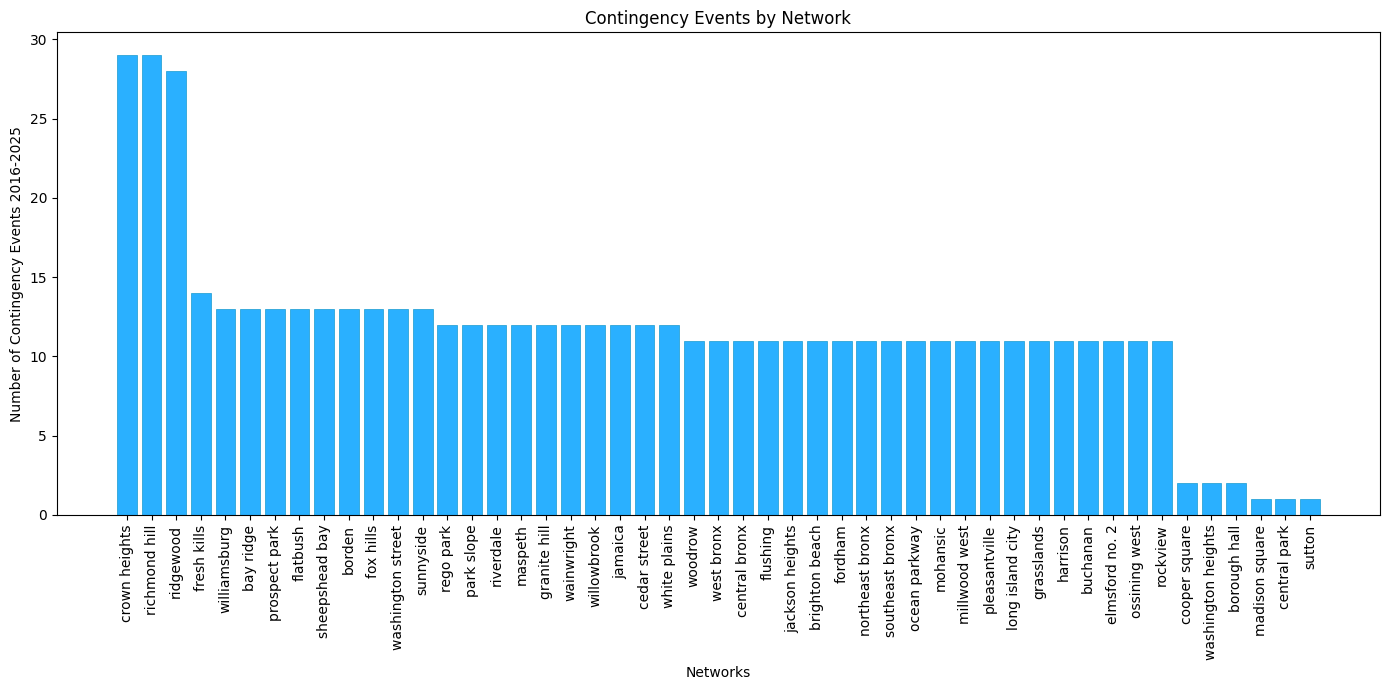

In [146]:
networkCounts = cexp_df['network'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14,7))
plt.bar(networkCounts.index, networkCounts.values,
        facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Contingency Events by Network')
plt.xlabel('Networks')
plt.xticks(rotation='vertical')
plt.ylabel('Number of Contingency Events 2016-2025')
plt.tight_layout()
plt.show()

In [155]:
clog_df['Zone/Network'].unique()

array(['Riverdale', 'Crown Heights', 'Ridgewood', 'Richmond Hill',
       'Sheepshead Bay', 'Williamsburg', 'Prospect Park', 'Central Park',
       'Madison Square', 'Cooper Square', 'Brownsville*', 'All^',
       'Flatbush', 'Willowbrook', 'Wainwright', 'Rego Park',
       'Non-Manhattan**', 'Maspeth', 'Non-Manhattan***', 'Borough Hall',
       'Bay Ridge', 'Fresh Kills', 'Park Slope', 'Fox Hills', 'Jamaica',
       'Sutton', 'White Plains', 'Washington Street', 'Cedar Street',
       'Borden', 'Sunnyside', 'Crown Heights, Richmond Hill, Ridgewood',
       'Granite Hill'], dtype=object)

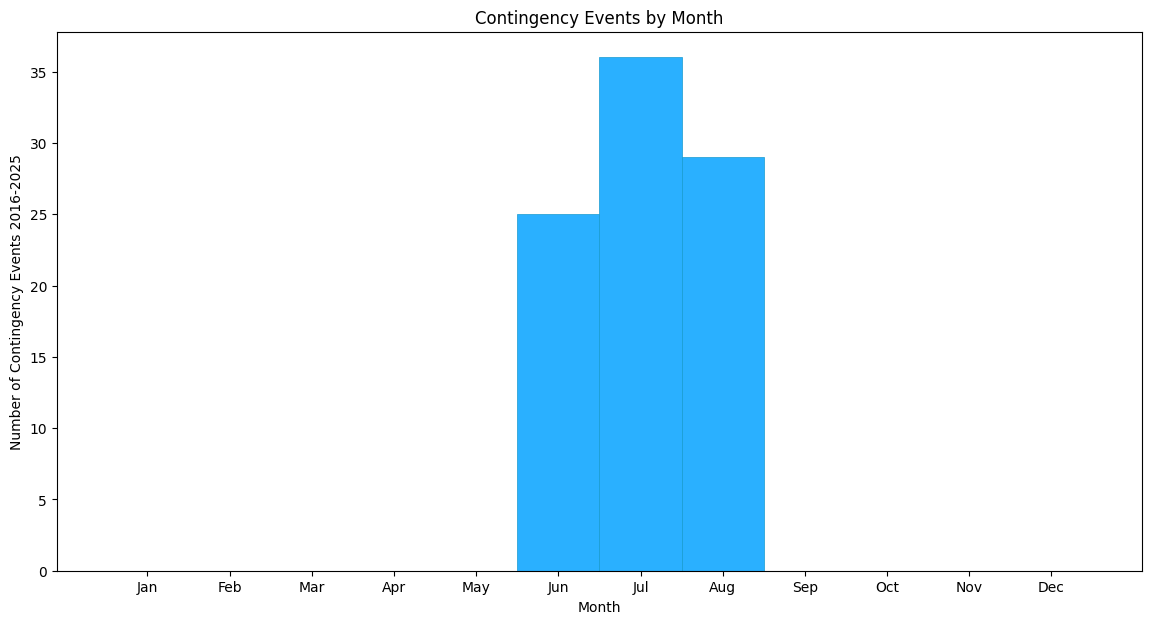

average month: 7.04
median month: 7.0
most common month: 7


In [150]:
plt.figure(figsize=(14,7))
plt.hist(clog_df['Month'], bins=range(1, 14), align='left',
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Contingency Events by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Number of Contingency Events 2016-2025')
plt.show()

print(f'average month: {clog_df["Month"].mean():.2f}')
print(f'median month: {clog_df["Month"].median()}')
print(f'most common month: {clog_df["Month"].mode().iloc[0]}')

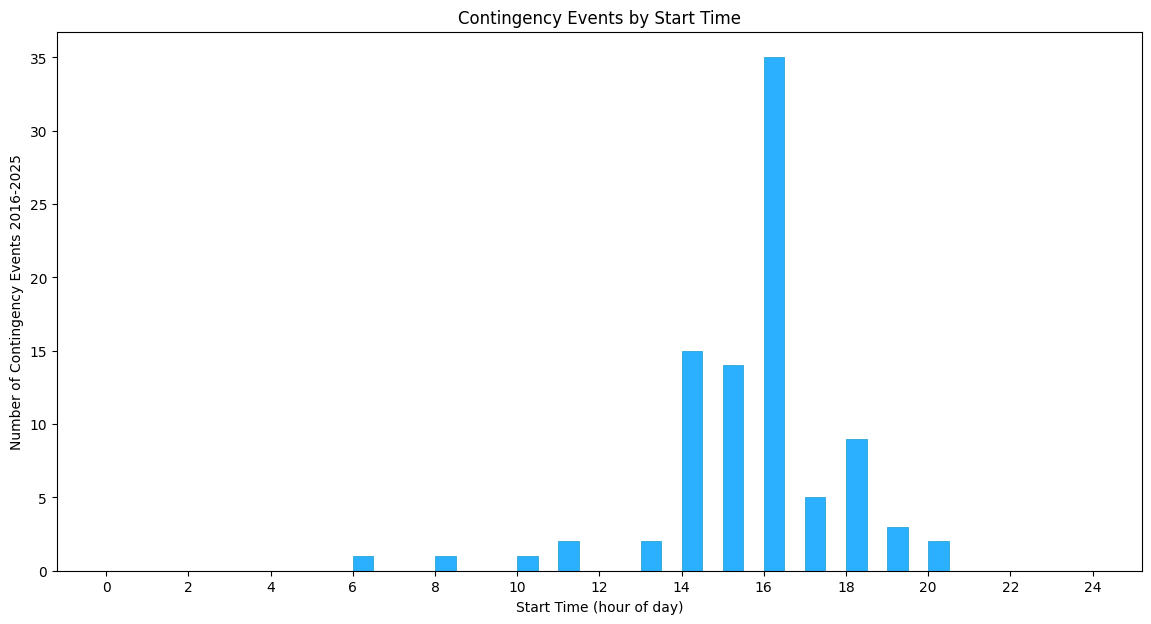

average start time: 15.51
median start time: 16.0
most common start time: 16.0

overall median event date: 2020-06-25


In [149]:
plt.figure(figsize=(14,7))
plt.hist(clog_df['Start Time Float'], bins=[h + m/60 for h in range(0, 25) for m in (0, 30)][:-1],
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('Contingency Events by Start Time')
plt.xlabel('Start Time (hour of day)')
plt.xticks(range(0, 25, 2))
plt.ylabel('Number of Contingency Events 2016-2025')
plt.show()

print(f'average start time: {clog_df["Start Time Float"].mean():.2f}')
print(f'median start time: {clog_df["Start Time Float"].median()}')
print(f'most common start time: {clog_df["Start Time Float"].mode().iloc[0]}')

print(f'\noverall median event date: {clog_df["Event Date"].median().date()}')

In [145]:
clog_df["Month"].median()

np.float64(7.0)

In [144]:
clog_df["Event Date"].median()

Timestamp('2020-06-25 12:00:00')

In [133]:
network_year_counts = cexp_df.groupby(['network', 'year']).size()
years_per_network = cexp_df.groupby('network')['year'].nunique()
events_per_network = cexp_df.groupby('network').size()

max_events_in_year = network_year_counts.max()
top_network_years = network_year_counts[network_year_counts == max_events_in_year]
print(f'Most contingency events a single network experienced in one year: {max_events_in_year}')
for (net, yr), count in top_network_years.items():
    print(f'  {net} in {yr}: {count} events')

max_years = years_per_network.max()
top_networks = years_per_network[years_per_network == max_years]
print(f'\nMaximum number of years any network experienced a contingency event: {max_years}')
for net, yrs in top_networks.items():
    print(f'  {net}: {yrs} years')

# nested: years-active buckets broken out by total event count
network_summary = pd.DataFrame({'years': years_per_network, 'events': events_per_network})
print('\nNumber of networks by years with a contingency event, broken out by event count:')
for num_years in sorted(network_summary['years'].unique()):
    subset = network_summary[network_summary['years'] == num_years]
    print(f'{num_years} year{"s" if num_years != 1 else ""}: {subset.shape[0]} networks')
    event_counts = subset['events'].value_counts().sort_index()
    for num_events, num_networks in event_counts.items():
        print(f'    {num_events} event{"s" if num_events != 1 else ""}: {num_networks} network{"s" if num_networks != 1 else ""}')

print(f'\nTotal networks with at least one contingency event: {years_per_network.shape[0]}')
print(f'Percentage of total networks: {years_per_network.shape[0]/networks_df.shape[0]:.1%}')

Most contingency events a single network experienced in one year: 13
  crown heights in 2020: 13 events
  richmond hill in 2020: 13 events
  ridgewood in 2020: 13 events

Maximum number of years any network experienced a contingency event: 5
  crown heights: 5 years
  ridgewood: 5 years

Number of networks by years with a contingency event, broken out by event count:
1 year: 4 networks
    1 event: 3 networks
    2 events: 1 network
2 years: 26 networks
    2 events: 2 networks
    11 events: 20 networks
    12 events: 4 networks
3 years: 13 networks
    12 events: 6 networks
    13 events: 7 networks
4 years: 4 networks
    13 events: 2 networks
    14 events: 1 network
    29 events: 1 network
5 years: 2 networks
    28 events: 1 network
    29 events: 1 network

Total networks with at least one contingency event: 49
Percentage of total networks: 59.0%


In [137]:
# --- Build separate flags for immediate vs. contingency vs. either ---
networksWithImmediate = set(exp_df['network'].unique())
networksWithContingency = set(cexp_df['network'].unique())

networks_flagged = networks_df.copy()
networks_flagged['had_immediate_event'] = networks_flagged['network'].isin(networksWithImmediate)
networks_flagged['had_contingency_event'] = networks_flagged['network'].isin(networksWithContingency)
networks_flagged['had_dlrp_event'] = networks_flagged['had_immediate_event'] | networks_flagged['had_contingency_event']
networks_flagged['borough_group'] = networks_flagged['borough'].apply(
    lambda b: 'staten island / westchester' if b in ['staten island', 'westchester'] else 'other'
)

print(f'Total networks: {networks_flagged.shape[0]}')
print(f'  Any DLRP event:      {networks_flagged["had_dlrp_event"].sum()} ({networks_flagged["had_dlrp_event"].mean():.1%})')
print(f'  Immediate event:     {networks_flagged["had_immediate_event"].sum()} ({networks_flagged["had_immediate_event"].mean():.1%})')
print(f'  Contingency event:   {networks_flagged["had_contingency_event"].sum()} ({networks_flagged["had_contingency_event"].mean():.1%})')


def print_breakdown(flag_col, label):
    print(f'\n=== {label} — likelihood by group ===')

    print('By tier:')
    for tier, group in networks_flagged.groupby('tier'):
        n = group.shape[0]
        hit = group[flag_col].sum()
        print(f'  Tier {tier}: {hit}/{n} networks ({hit/n:.1%})')

    print('By borough:')
    for borough, group in networks_flagged.groupby('borough'):
        n = group.shape[0]
        hit = group[flag_col].sum()
        print(f'  {borough}: {hit}/{n} networks ({hit/n:.1%})')

    print('By borough group:')
    for group_name, group in networks_flagged.groupby('borough_group'):
        n = group.shape[0]
        hit = group[flag_col].sum()
        print(f'  {group_name}: {hit}/{n} networks ({hit/n:.1%})')

    print('By scheduled start time:')
    for start_time, group in networks_flagged.groupby('start time'):
        n = group.shape[0]
        hit = group[flag_col].sum()
        print(f'  {start_time}: {hit}/{n} networks ({hit/n:.1%})')


print_breakdown('had_immediate_event', 'Immediate Events')
print_breakdown('had_contingency_event', 'Contingency Events')
print_breakdown('had_dlrp_event', 'Any DLRP Event (combined)')

Total networks: 83
  Any DLRP event:      53 (63.9%)
  Immediate event:     31 (37.3%)
  Contingency event:   49 (59.0%)

=== Immediate Events — likelihood by group ===
By tier:
  Tier 1: 23/73 networks (31.5%)
  Tier 2: 8/10 networks (80.0%)
By borough:
  bronx: 3/6 networks (50.0%)
  brooklyn: 7/11 networks (63.6%)
  manhattan: 5/39 networks (12.8%)
  queens: 5/9 networks (55.6%)
  staten island: 3/5 networks (60.0%)
  westchester: 8/13 networks (61.5%)
By borough group:
  other: 20/65 networks (30.8%)
  staten island / westchester: 11/18 networks (61.1%)
By scheduled start time:
  11:00: 1/21 networks (4.8%)
  14:00: 2/16 networks (12.5%)
  16:00: 23/38 networks (60.5%)
  19:00: 5/8 networks (62.5%)

=== Contingency Events — likelihood by group ===
By tier:
  Tier 1: 39/73 networks (53.4%)
  Tier 2: 10/10 networks (100.0%)
By borough:
  bronx: 6/6 networks (100.0%)
  brooklyn: 11/11 networks (100.0%)
  manhattan: 5/39 networks (12.8%)
  queens: 9/9 networks (100.0%)
  staten island:

In [130]:
uC = getUnique(clog_df['Zone/Network'].unique())
print(uC)
print('number of networks with contingency events:')
#number of networks with contingency events
print(len(uC))
#percentage with contingency events
print('percentage with contingency events:')
print(len(uC)/networks_df.shape[0])
#uC


['riverdale', 'crown heights', 'ridgewood', 'richmond hill', 'sheepshead bay', 'williamsburg', 'prospect park', 'central park', 'madison square', 'cooper square', 'central bronx', 'fordham', 'northeast bronx', 'southeast bronx', 'west bronx', 'bay ridge', 'brighton beach', 'flatbush', 'ocean parkway', 'park slope', 'borden', 'flushing', 'jackson heights', 'jamaica', 'long island city', 'maspeth', 'rego park', 'sunnyside', 'fox hills', 'fresh kills', 'wainwright', 'willowbrook', 'woodrow', 'buchanan', 'cedar street', 'elmsford no. 2', 'granite hill', 'grasslands', 'harrison', 'millwood west', 'mohansic', 'washington street', 'white plains', 'pleasantville', 'rockview', 'ossining west', 'washington heights', 'borough hall', 'sutton']
number of networks with contingency events:
49
percentage with contingency events:
0.5903614457831325


In [151]:
print(f'Median contingency events per network-year (network-years w/ 1+ events): {network_year_counts.median()}')
print(f'Mean contingency events per network-year: {network_year_counts.mean():.2f}')
print(f'n = {network_year_counts.shape[0]} network-years')

# distribution for context
print('\nDistribution of contingency events per active network-year:')
print(network_year_counts.value_counts().sort_index())

Median contingency events per network-year (network-years w/ 1+ events): 3.0
Mean contingency events per network-year: 4.68
n = 121 network-years

Distribution of contingency events per active network-year:
1     22
2      7
3     38
4      4
5      4
6      3
8     37
9      3
13     3
Name: count, dtype: int64


In [189]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# distribute a typical (median) network-year's worth of contingency events across months,
# based on the overall historical proportion of contingency events falling in each month
month_counts = cexp_df['month'].value_counts().sort_index()
month_proportions = month_counts / month_counts.sum()

typical_events_per_network_year = network_year_counts.median()  # 3

expected_events_by_month = (month_proportions * typical_events_per_network_year).round(2)

print(f'Median contingency events per active network-year: {typical_events_per_network_year}')
print('\nHistorical proportion of contingency events by month (all networks/years combined):')
for month, prop in month_proportions.items():
    print(f'  {month_names[month-1]}: {prop:.1%} ({month_counts[month]} of {month_counts.sum()} events)')

print(f'\nExpected events per month in a typical ({typical_events_per_network_year}-event) network-year:')
for month, expected in expected_events_by_month.items():
    print(f'  {month_names[month-1]}: {expected}')

Median contingency events per active network-year: 3.0

Historical proportion of contingency events by month (all networks/years combined):
  Jun: 7.2% (41 of 566 events)
  Jul: 87.6% (496 of 566 events)
  Aug: 5.1% (29 of 566 events)

Expected events per month in a typical (3.0-event) network-year:
  Jun: 0.22
  Jul: 2.63
  Aug: 0.15


In [190]:
print(f'Networks with at least one contingency event: {years_per_network.shape[0]}')

print(f'\nMedian total contingency events per network (across their entire active history): {events_per_network.median()}')
print(f'Mean total contingency events per network: {events_per_network.mean():.2f}')

print(f'\nMedian number of distinct years spread across: {years_per_network.median()}')
print(f'Mean number of distinct years spread across: {years_per_network.mean():.2f}')

# combined view for context
network_summary = pd.DataFrame({'total_events': events_per_network, 'years_active': years_per_network})
print('\nFull distribution:')
print(network_summary.describe())

Networks with at least one contingency event: 49

Median total contingency events per network (across their entire active history): 11.0
Mean total contingency events per network: 11.55

Median number of distinct years spread across: 2.0
Mean number of distinct years spread across: 2.47

Full distribution:
       total_events  years_active
count     49.000000     49.000000
mean      11.551020      2.469388
std        5.627541      0.915197
min        1.000000      1.000000
25%       11.000000      2.000000
50%       11.000000      2.000000
75%       13.000000      3.000000
max       29.000000      5.000000


## Correlation between immediate and contingency events

Per-network totals (immediate vs. contingency events):
  Pearson r  = 0.255 (p = 0.0649)
  Spearman rho = 0.382 (p = 0.0048)
  n = 53 networks


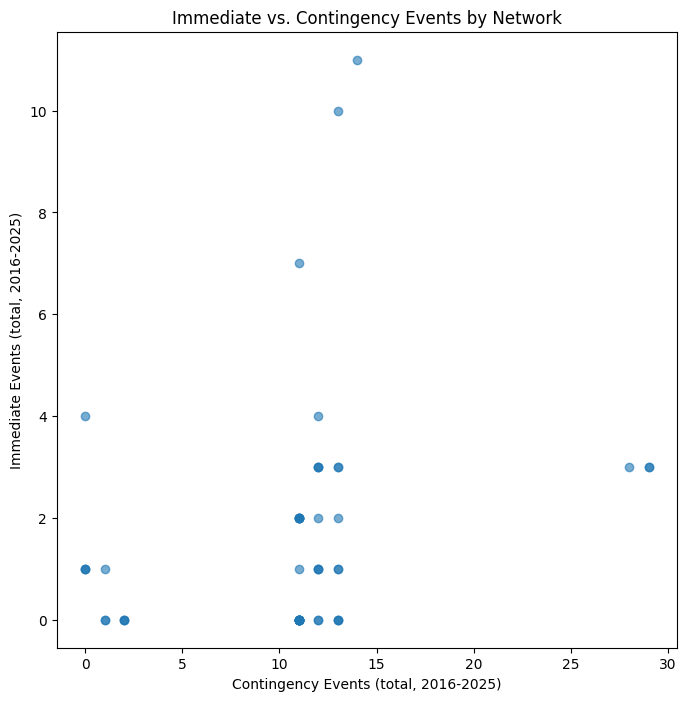


Per-year totals (immediate vs. contingency events, aggregated across networks):
  Pearson r  = -0.293 (p = 0.4117)
  Spearman rho = -0.284 (p = 0.4266)
  n = 10 years


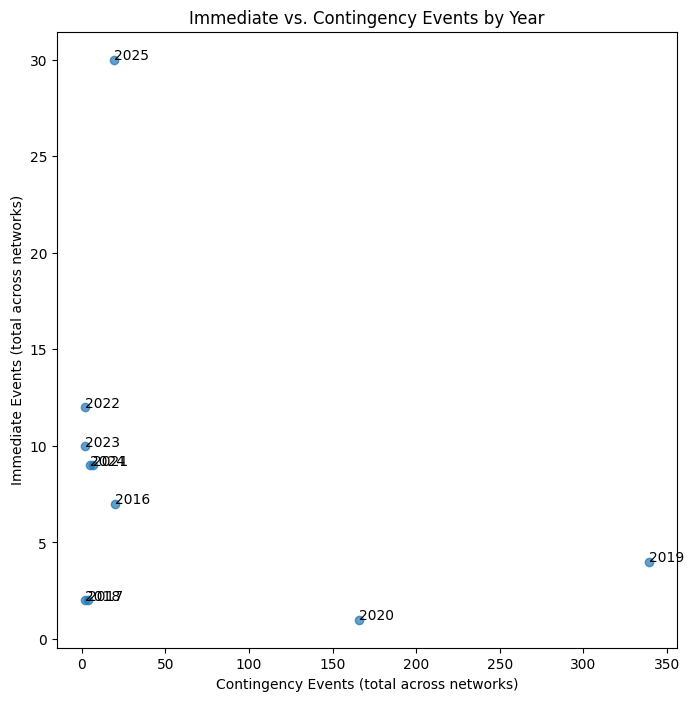

In [135]:
from scipy import stats

# --- Per-network level ---
# rebuild totals from the exploded dataframes (immediate = exp_df, contingency = cexp_df)
immediate_totals = exp_df.groupby('network').size().rename('immediate_events')
contingency_totals = cexp_df.groupby('network').size().rename('contingency_events')

# outer join + fill 0, since a network may have one type of event but not the other
network_totals = pd.concat([immediate_totals, contingency_totals], axis=1).fillna(0)

pearson_r, pearson_p = stats.pearsonr(network_totals['immediate_events'], network_totals['contingency_events'])
spearman_r, spearman_p = stats.spearmanr(network_totals['immediate_events'], network_totals['contingency_events'])

print('Per-network totals (immediate vs. contingency events):')
print(f'  Pearson r  = {pearson_r:.3f} (p = {pearson_p:.4f})')
print(f'  Spearman rho = {spearman_r:.3f} (p = {spearman_p:.4f})')
print(f'  n = {network_totals.shape[0]} networks')

plt.figure(figsize=(8,8))
plt.scatter(network_totals['contingency_events'], network_totals['immediate_events'], alpha=0.6)
plt.title('Immediate vs. Contingency Events by Network')
plt.xlabel('Contingency Events (total, 2016-2025)')
plt.ylabel('Immediate Events (total, 2016-2025)')
plt.show()

# --- Per-year level (aggregated across all networks) ---
immediate_by_year = exp_df.groupby('year').size().rename('immediate_events')
contingency_by_year = cexp_df.groupby('year').size().rename('contingency_events')

year_totals = pd.concat([immediate_by_year, contingency_by_year], axis=1).fillna(0)

pearson_r_y, pearson_p_y = stats.pearsonr(year_totals['immediate_events'], year_totals['contingency_events'])
spearman_r_y, spearman_p_y = stats.spearmanr(year_totals['immediate_events'], year_totals['contingency_events'])

print('\nPer-year totals (immediate vs. contingency events, aggregated across networks):')
print(f'  Pearson r  = {pearson_r_y:.3f} (p = {pearson_p_y:.4f})')
print(f'  Spearman rho = {spearman_r_y:.3f} (p = {spearman_p_y:.4f})')
print(f'  n = {year_totals.shape[0]} years')

plt.figure(figsize=(8,8))
plt.scatter(year_totals['contingency_events'], year_totals['immediate_events'], alpha=0.7)
for yr in year_totals.index:
    plt.annotate(str(yr), (year_totals.loc[yr, 'contingency_events'], year_totals.loc[yr, 'immediate_events']))
plt.title('Immediate vs. Contingency Events by Year')
plt.xlabel('Contingency Events (total across networks)')
plt.ylabel('Immediate Events (total across networks)')
plt.show()

## CSRP Analysis

Total CSRP event rows: 159

Unique CSRP event days: 30

CSRP events by year:
Event Date
2016    4
2018    4
2019    4
2020    3
2021    4
2022    6
2023    2
2024    3
dtype: int64

average CSRP events per year: 3.75
median CSRP events per year: 4.0


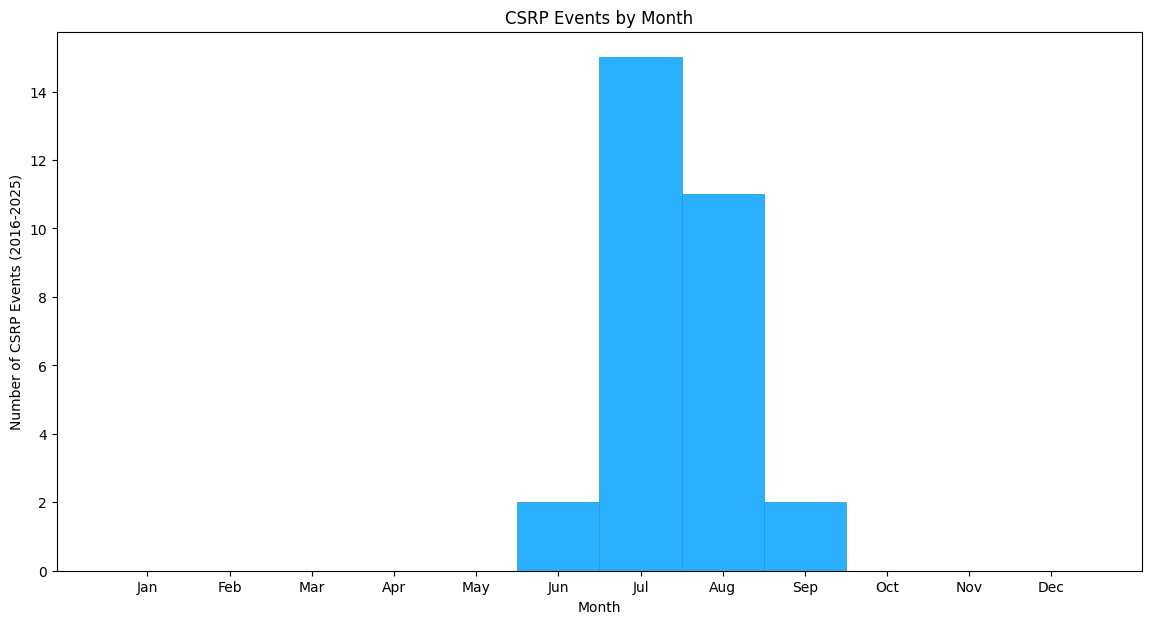


average month: 7.43
median month: 7.0
most common month: 7


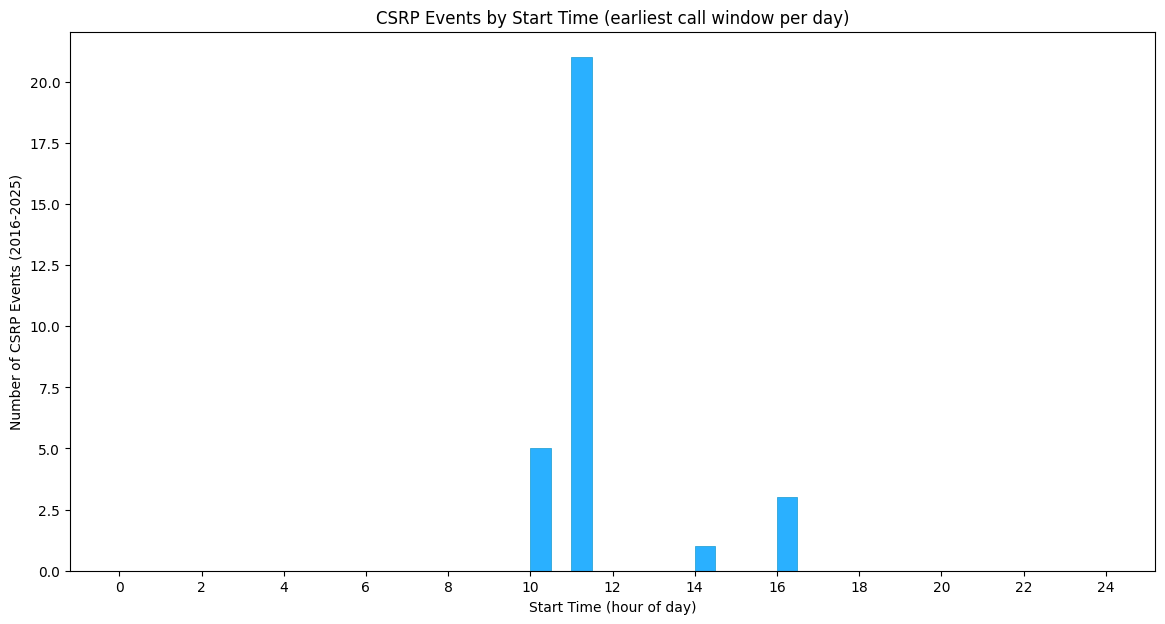


average start time: 11.43
median start time: 11.0
most common start time: 11.0

overall median event date: 2021-01-12


In [187]:
## CSRP Analysis

# filter to CSRP events only
rlog_df = flog_df[flog_df['Program'].isin(['CSRP'])].copy()
print(f'Total CSRP event rows: {rlog_df.shape[0]}')

# CSRP events are called system-wide ('All'-type Zone/Network values), but the same
# calendar-day event is often logged as multiple rows for different call windows
# (e.g. separate 11am/2pm/4pm/7pm windows). To analyze actual CSRP *events* (as opposed
# to logged call-window rows), collapse to one row per calendar day, using the earliest
# start time logged that day as the event's start time.
all_type_networks = ['All', 'All^', 'Non-Manhattan**', 'Non-Manhattan***']
rlog_all_df = rlog_df[rlog_df['Zone/Network'].isin(all_type_networks)].copy()

rlog_all_df['DT Format'] = pd.to_datetime(rlog_all_df['Start Time'], format='%H:%M')
rlog_all_df['Start Time Float'] = rlog_all_df['DT Format'].dt.hour + (rlog_all_df['DT Format'].dt.minute / 60)

rEvents_df = rlog_all_df.groupby(rlog_all_df['Event Date'].dt.date).agg(
    **{'Event Date': ('Event Date', 'first'),
       'Start Time Float': ('Start Time Float', 'min')}
).reset_index(drop=True)

print(f'\nUnique CSRP event days: {rEvents_df.shape[0]}')

yS = rEvents_df.groupby(rEvents_df['Event Date'].dt.year).size()
print('\nCSRP events by year:')
print(yS)
print(f'\naverage CSRP events per year: {yS.mean():.2f}')
print(f'median CSRP events per year: {yS.median()}')

# 2020 had an unusually high number of separately-logged, non-'All' CSRP call windows
# (COVID-era operational changes); filtering to 'All'-type rows above avoids that
# inflating the day-level count for that year.

# --- When in the year do CSRP events occur? ---
rEvents_df['Month'] = rEvents_df['Event Date'].dt.month

plt.figure(figsize=(14,7))
plt.hist(rEvents_df['Month'], bins=range(1, 14), align='left',
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('CSRP Events by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Number of CSRP Events (2016-2025)')
plt.show()

print(f'\naverage month: {rEvents_df["Month"].mean():.2f}')
print(f'median month: {rEvents_df["Month"].median()}')
print(f'most common month: {rEvents_df["Month"].mode().iloc[0]}')

# --- What time of day do CSRP events start? (earliest call window per day) ---
plt.figure(figsize=(14,7))
plt.hist(rEvents_df['Start Time Float'], bins=[h + m/60 for h in range(0, 25) for m in (0, 30)][:-1],
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('CSRP Events by Start Time (earliest call window per day)')
plt.xlabel('Start Time (hour of day)')
plt.xticks(range(0, 25, 2))
plt.ylabel('Number of CSRP Events (2016-2025)')
plt.show()

print(f'\naverage start time: {rEvents_df["Start Time Float"].mean():.2f}')
print(f'median start time: {rEvents_df["Start Time Float"].median()}')
print(f'most common start time: {rEvents_df["Start Time Float"].mode().iloc[0]}')

print(f'\noverall median event date: {rEvents_df["Event Date"].median().date()}')

In [188]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# distribute a typical (median) 4-event year across months, based on the overall
# historical proportion of events falling in each month
month_counts = rEvents_df['Month'].value_counts().sort_index()
month_proportions = month_counts / month_counts.sum()

typical_events_per_year = yS.median()  # 4

expected_events_by_month = (month_proportions * typical_events_per_year).round(2)

print(f'Median CSRP events per year: {typical_events_per_year}')
print('\nHistorical proportion of CSRP events by month (all years combined):')
for month, prop in month_proportions.items():
    print(f'  {month_names[month-1]}: {prop:.1%} ({month_counts[month]} of {month_counts.sum()} events)')

print(f'\nExpected events per month in a typical ({typical_events_per_year}-event) year:')
for month, expected in expected_events_by_month.items():
    print(f'  {month_names[month-1]}: {expected}')

Median CSRP events per year: 4.0

Historical proportion of CSRP events by month (all years combined):
  Jun: 6.7% (2 of 30 events)
  Jul: 50.0% (15 of 30 events)
  Aug: 36.7% (11 of 30 events)
  Sep: 6.7% (2 of 30 events)

Expected events per month in a typical (4.0-event) year:
  Jun: 0.27
  Jul: 2.0
  Aug: 1.47
  Sep: 0.27


In [178]:
#filter out non CSRP events
rlog_df = flog_df[flog_df['Program'].isin(['CSRP'])]

print(rlog_df.shape)
rlog_df.head()

(159, 9)


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
178,2016-07-25,Con Edison,CSRP,11:00,15:00,4:00,All,Event,Planned
179,2016-07-25,Con Edison,CSRP,14:00,18:00,4:00,All,Event,Planned
180,2016-07-25,Con Edison,CSRP,16:00,20:00,4:00,All,Event,Planned
181,2016-07-25,Con Edison,CSRP,19:00,23:00,4:00,All,Event,Planned
187,2016-07-26,Con Edison,CSRP,11:00,15:00,4:00,All,Event,Planned


In [179]:
rlog_df.tail()

,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
958,2025-06-24,Con Edison,CSRP,10:00,23:00,4:00,System Wide,Event,CSRP Planned
966,2025-06-25,Con Edison,CSRP,10:00,23:00,4:00,System Wide,Event,CSRP Planned
993,2025-07-17,Con Edison,CSRP,10:00,23:00,4:00,System Wide,Event,CSRP Planned
1008,2025-07-29,Con Edison,CSRP,10:00,23:00,4:00,System Wide,Event,CSRP Planned
1011,2025-07-30,Con Edison,CSRP,10:00,23:00,4:00,System Wide,Event,CSRP Planned


In [180]:
# this shows that more than 4 CSRP events per year for a given network is rare
# 2020 is an outlier in that it had many CSRP events that weren't for the entire network

# merge by day because CSRP events typically happen for all networks but redudant events are logged by call time
rD_s = rlog_df.groupby(rlog_df['Event Date'].dt.date).size()#.rename(columns={'size':'sum'})
#make a new data frame of event days
rY_s = pd.DataFrame({'dates':pd.to_datetime(rD_s.keys())})
#regroup by year
rY_s.groupby(rY_s['dates'].dt.year).size()

dates
2016     4
2018     4
2019     4
2020    19
2021     4
2022     6
2023     2
2024     3
2025     6
dtype: int64

In [181]:
rD_s

Event Date
2016-07-25     4
2016-07-26     4
2016-08-12     3
2016-08-15     4
2018-07-02     4
2018-08-28     4
2018-08-29     4
2018-09-06     4
2019-07-19     4
2019-07-20     4
2019-07-21     4
2019-08-19     4
2020-06-21     1
2020-06-25     1
2020-06-26     1
2020-06-27     1
2020-06-28     1
2020-06-29     1
2020-06-30     1
2020-07-01     1
2020-07-02     1
2020-07-05     1
2020-07-06     1
2020-07-07     1
2020-07-09     1
2020-07-20     1
2020-07-22     1
2020-07-27     2
2020-07-28     2
2020-07-29     1
2020-07-30     1
2021-06-29     4
2021-06-30     4
2021-08-12     4
2021-08-13     4
2022-07-20     4
2022-07-21     4
2022-08-04     4
2022-08-05     4
2022-08-08     4
2022-08-09     4
2023-07-28     7
2023-09-07     8
2024-07-15    10
2024-07-16    10
2024-07-17    10
2025-06-23     1
2025-06-24     1
2025-06-25     1
2025-07-17     1
2025-07-29     1
2025-07-30     1
dtype: int64

In [182]:
# this shows that more than 4 CSRP events per year for a given network is rare
# 2020 is an outlier in that it had many CSRP events that weren't for the entire network

# merge by day because CSRP events typically happen for all networks but redudant events are logged by call time
rD_s = rlog_df[rlog_df['Zone/Network'].isin(['All','All^','Non-Manhattan**','Non-Manhattan***'])].groupby(rlog_df['Event Date'].dt.date).size()#.rename(columns={'size':'sum'})
#make a new data frame of event days
rY_s = pd.DataFrame({'dates':pd.to_datetime(rD_s.keys())})

#regroup by year
yS = rY_s.groupby(rY_s['dates'].dt.year).size()

#add 0 'all' events in to 2020
#yS.at['2020']=0

yS

dates
2016    4
2018    4
2019    4
2020    3
2021    4
2022    6
2023    2
2024    3
dtype: int64

In [183]:
#average 'all' events
yS.mean()

np.float64(3.75)

In [184]:
yS.median()

np.float64(4.0)

In [185]:
median([4,4,4,3,4,2,3])

4

In [186]:
yS

dates
2016    4
2018    4
2019    4
2020    3
2021    4
2022    6
2023    2
2024    3
dtype: int64

## DLRP Test Event Analysis

In [175]:
#filter out NYISO
tlog_df = log_df[log_df['Administrator']=='Con Edison']

#filter out non DLRP events
tlog_df = tlog_df[tlog_df['Program'].isin(['DLRP'])]

#filter out non-Test events
tlog_df = tlog_df[tlog_df['Event/Test'] == 'Test']

pd.set_option('display.max_rows', None)  # or 1000
display(tlog_df)

,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
1,2011-06-08,Con Edison,DLRP,15:00,16:00,1:00,All,Test,NaN
69,2013-06-26,Con Edison,DLRP,12:00,13:00,1:00,All,Test,NaN
118,2014-06-26,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
148,2015-06-24,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
168,2016-07-13,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
273,2017-07-18,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
276,2017-07-31,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
330,2018-07-16,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test
502,2019-08-20,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
593,2020-08-24,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test


In [176]:
#filter out pre-2016 data
tlog_df[tlog_df['Event Date'] > datetime.strptime('2016-01-01', '%Y-%m-%d')]

,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
168,2016-07-13,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
273,2017-07-18,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
276,2017-07-31,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
330,2018-07-16,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test
502,2019-08-20,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
593,2020-08-24,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test
646,2021-07-27,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
685,2022-07-18,Con Edison,DLRP,16:30,18:30,2:00,All,Test,Test
800,2022-07-14,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
987,2025-07-16,Con Edison,DLRP,16:00,18:00,2:00,System Wide,Test,DLRP Test


,Event Date,Administrator,Program,Start Time,End Time,Event Duration,Zone/Network,Event/Test,Event Type
168,2016-07-13,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
273,2017-07-18,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
276,2017-07-31,Con Edison,DLRP,16:00,17:00,1:00,All,Test,NaN
330,2018-07-16,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test
502,2019-08-20,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
593,2020-08-24,Con Edison,DLRP,14:00,16:00,2:00,All,Test,Test
646,2021-07-27,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
685,2022-07-18,Con Edison,DLRP,16:30,18:30,2:00,All,Test,Test
800,2022-07-14,Con Edison,DLRP,16:00,18:00,2:00,All,Test,Test
987,2025-07-16,Con Edison,DLRP,16:00,18:00,2:00,System Wide,Test,DLRP Test


Total DLRP test events (2016+): 10

DLRP test events by year:
Event Date
2016    1
2017    2
2018    1
2019    1
2020    1
2021    1
2022    2
2025    1
dtype: int64

average DLRP test events per year: 1.25
median DLRP test events per year: 1.0

Unique Zone/Network values in DLRP test events: ['All', 'System Wide']


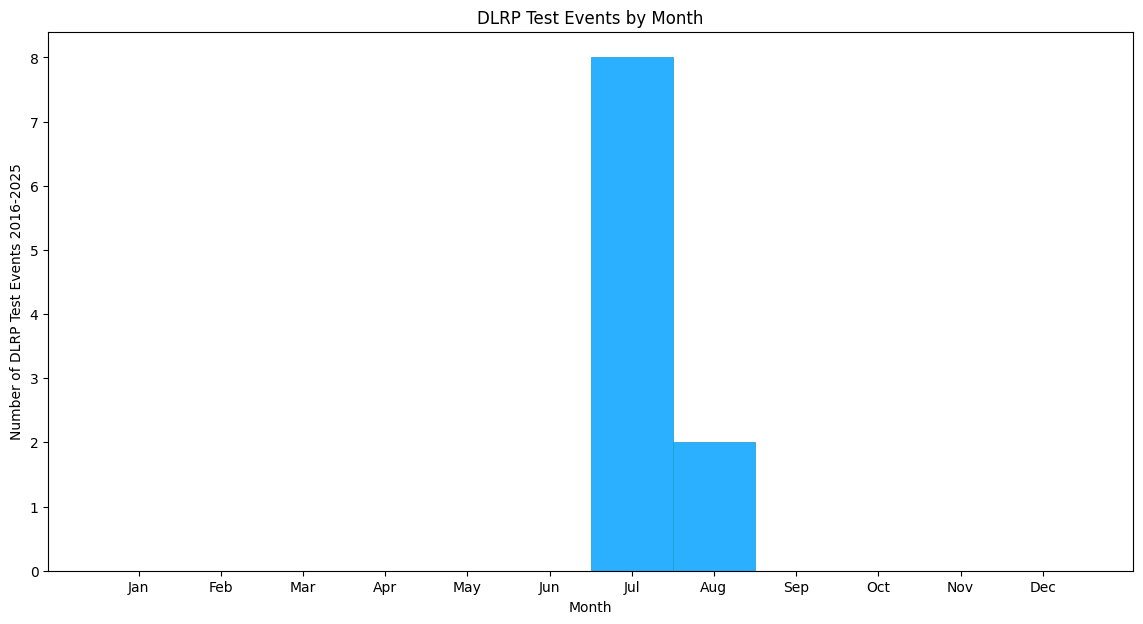


average month: 7.20
median month: 7.0
most common month: 7


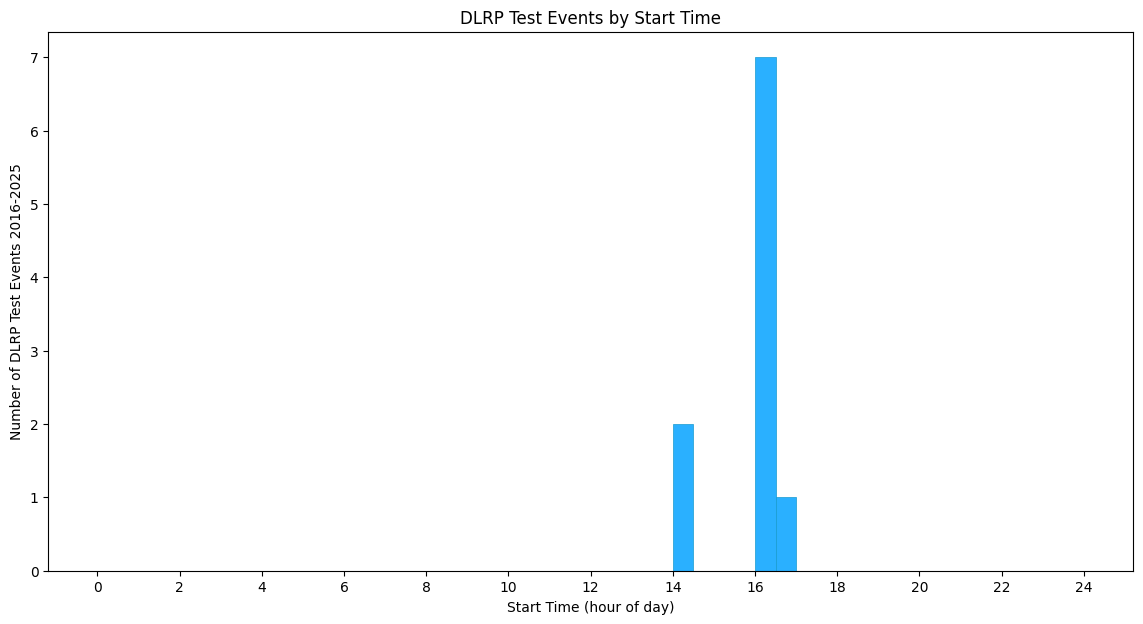


average start time: 15.65
median start time: 16.0
most common start time: 16.0

overall median event date: 2020-02-21


In [177]:
## DLRP Test Event Analysis

# filter out NYISO administered events, keep only Con Edison
tlog_df = log_df[log_df['Administrator'] == 'Con Edison'].copy()

# filter to DLRP program only
tlog_df = tlog_df[tlog_df['Program'].isin(['DLRP'])]

# filter to Test events only (Event/Test == 'Test')
tlog_df = tlog_df[tlog_df['Event/Test'] == 'Test']

# filter to post-2016 (matches the cutoff used elsewhere in the notebook)
tlog_df = tlog_df[tlog_df['Event Date'] > datetime.strptime('2016-01-01', '%Y-%m-%d')].copy()

pd.set_option('display.max_rows', None)
display(tlog_df)

print(f'Total DLRP test events (2016+): {tlog_df.shape[0]}')

# --- Per-year counts ---
tY_s = tlog_df.groupby(tlog_df['Event Date'].dt.year).size()
print('\nDLRP test events by year:')
print(tY_s)

print(f'\naverage DLRP test events per year: {tY_s.mean():.2f}')
print(f'median DLRP test events per year: {tY_s.median()}')

# --- Sanity check: are DLRP tests always logged against "All"? ---
unique_networks = tlog_df['Zone/Network'].unique()
print(f'\nUnique Zone/Network values in DLRP test events: {list(unique_networks)}')

# --- When in the year do tests occur? ---
tlog_df['Month'] = tlog_df['Event Date'].dt.month

plt.figure(figsize=(14,7))
plt.hist(tlog_df['Month'], bins=range(1, 14), align='left',
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('DLRP Test Events by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Number of DLRP Test Events 2016-2025')
plt.show()

print(f'\naverage month: {tlog_df["Month"].mean():.2f}')
print(f'median month: {tlog_df["Month"].median()}')
print(f'most common month: {tlog_df["Month"].mode().iloc[0]}')

# --- What time of day do tests start? ---
tlog_df['DT Format'] = pd.to_datetime(tlog_df['Start Time'], format='%H:%M')
tlog_df['Start Time Float'] = tlog_df['DT Format'].dt.hour + (tlog_df['DT Format'].dt.minute / 60)

plt.figure(figsize=(14,7))
plt.hist(tlog_df['Start Time Float'], bins=[h + m/60 for h in range(0, 25) for m in (0, 30)][:-1],
         facecolor='#2ab0ff', edgecolor='#169acf', linewidth=0.5)
plt.title('DLRP Test Events by Start Time')
plt.xlabel('Start Time (hour of day)')
plt.xticks(range(0, 25, 2))
plt.ylabel('Number of DLRP Test Events 2016-2025')
plt.show()

print(f'\naverage start time: {tlog_df["Start Time Float"].mean():.2f}')
print(f'median start time: {tlog_df["Start Time Float"].median()}')
print(f'most common start time: {tlog_df["Start Time Float"].mode().iloc[0]}')

print(f'\noverall median event date: {tlog_df["Event Date"].median().date()}')